# S&P 500 ETF (IVE) Bid/Ask Minute Data Exploration

This notebook explores the minute-level bid/ask data for the **IVE ETF (iShares S&P 500 Value ETF)** located in `IVE_bidask1min.txt`.

Our goal is to:
1. Parse and clean the dataset.
2. Engineer relevant market features (Mid-Price, Spread, Log Returns).
3. Visualize price and spread patterns.
4. Formulate how to structure this data into sequential **state trajectories** ready for a JEPA (Joint Embedding Predictive Architecture) model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

### Loading and Formatting the Data

The data file has no headers. Based on your target schema, the columns represent:
* `Date` (MM/DD/YYYY)
* `Time` (HH:MM)
* `Open`, `High`, `Low`, `Close`, `Volume` (Trade details)
* `BidOpen`, `BidHigh`, `BidLow`, `BidClose` (Bid details)
* `AskOpen`, `AskHigh`, `AskLow`, `AskClose` (Ask details)

In [2]:
columns = [
    'Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume',
    'BidOpen', 'BidHigh', 'BidLow', 'BidClose',
    'AskOpen', 'AskHigh', 'AskLow', 'AskClose'
]

print("Loading dataset...")
with open('IVE_bidask1min.txt', 'r') as f:
    num_cols = len(f.readline().split(','))

if num_cols == 10:
    print("Detected 10-column file format. Mapping Bid/Ask fields and creating trade placeholders.")
    actual_cols = [
        'Date', 'Time', 
        'AskOpen', 'AskHigh', 'AskLow', 'AskClose', 
        'BidOpen', 'BidHigh', 'BidLow', 'BidClose'
    ]
    df = pd.read_csv('IVE_bidask1min.txt', header=None, names=actual_cols)
    # Fill trade column placeholders
    df['Open'] = df['AskOpen']
    df['High'] = df['AskHigh']
    df['Low'] = df['AskLow']
    df['Close'] = (df['AskClose'] + df['BidClose']) / 2.0
    df['Volume'] = 0
else:
    print("Detected 15-column file format.")
    df = pd.read_csv('IVE_bidask1min.txt', header=None, names=columns)
print(f"Loaded {len(df):,} rows.")

Loading dataset...
Detected 10-column file format. Mapping Bid/Ask fields and creating trade placeholders.


Loaded 1,394,546 rows.


In [3]:
# Combine Date and Time into a single Datetime Index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)
df.head()

,AskOpen,AskHigh,AskLow,AskClose,BidOpen,BidHigh,BidLow,BidClose,Open,High,Low,Close,Volume
Datetime,,,,,,,,,,,,,
2009-09-28 09:30:00,35.00,35.00,35.00,35.00,35.00,35.00,35.00,35.00,35.00,35.00,35.00,35.000,0
2009-09-28 09:31:00,35.04,35.04,35.04,35.04,35.02,35.02,35.02,35.02,35.04,35.04,35.04,35.030,0
2009-09-28 09:32:00,35.08,35.08,35.08,35.08,35.04,35.04,35.04,35.04,35.08,35.08,35.08,35.060,0
2009-09-28 09:33:00,35.07,35.07,35.07,35.07,35.07,35.07,35.07,35.07,35.07,35.07,35.07,35.070,0
2009-09-28 09:34:00,35.07,35.07,35.07,35.07,35.06,35.06,35.06,35.06,35.07,35.07,35.07,35.065,0


### Feature Engineering

For predicting prices and modeling the market state, we calculate basic indicators:
1. **Mid-Price**: The average of the Close Ask and Close Bid.
2. **Spread**: The difference between Close Ask and Close Bid.
3. **Log Returns**: The percentage change in mid-price over time.

In [4]:
# Compute Mid-Price and Spread
df['Mid_Price'] = (df['AskClose'] + df['BidClose']) / 2.0
df['Spread'] = df['AskClose'] - df['BidClose']

# Compute Log Returns of the Mid-Price
df['Log_Return'] = np.log(df['Mid_Price'] / df['Mid_Price'].shift(1))

# Inspect statistics of engineered features
df[['Mid_Price', 'Spread', 'Log_Return']].describe()

,Mid_Price,Spread,Log_Return
count,1.394546e+06,1.394546e+06,1.394545e+06
mean,1.018473e+02,2.304540e-02,1.343145e-06
std,4.972983e+01,8.234201e-02,5.635077e-03
min,1.117000e-01,0.000000e+00,-4.571003e+00
25%,6.555500e+01,0.000000e+00,-1.567460e-04
50%,9.249000e+01,1.000000e-02,0.000000e+00
75%,1.368650e+02,3.000000e-02,1.597742e-04
max,2.285350e+02,3.484020e+01,3.141002e+00


### Visualizing a Sample Day

Let's look at the first trading day in the dataset and plot the Mid-Price (with the Bid/Ask range shaded) and the Bid-Ask spread.

Plotting for sample date: 2009-09-28


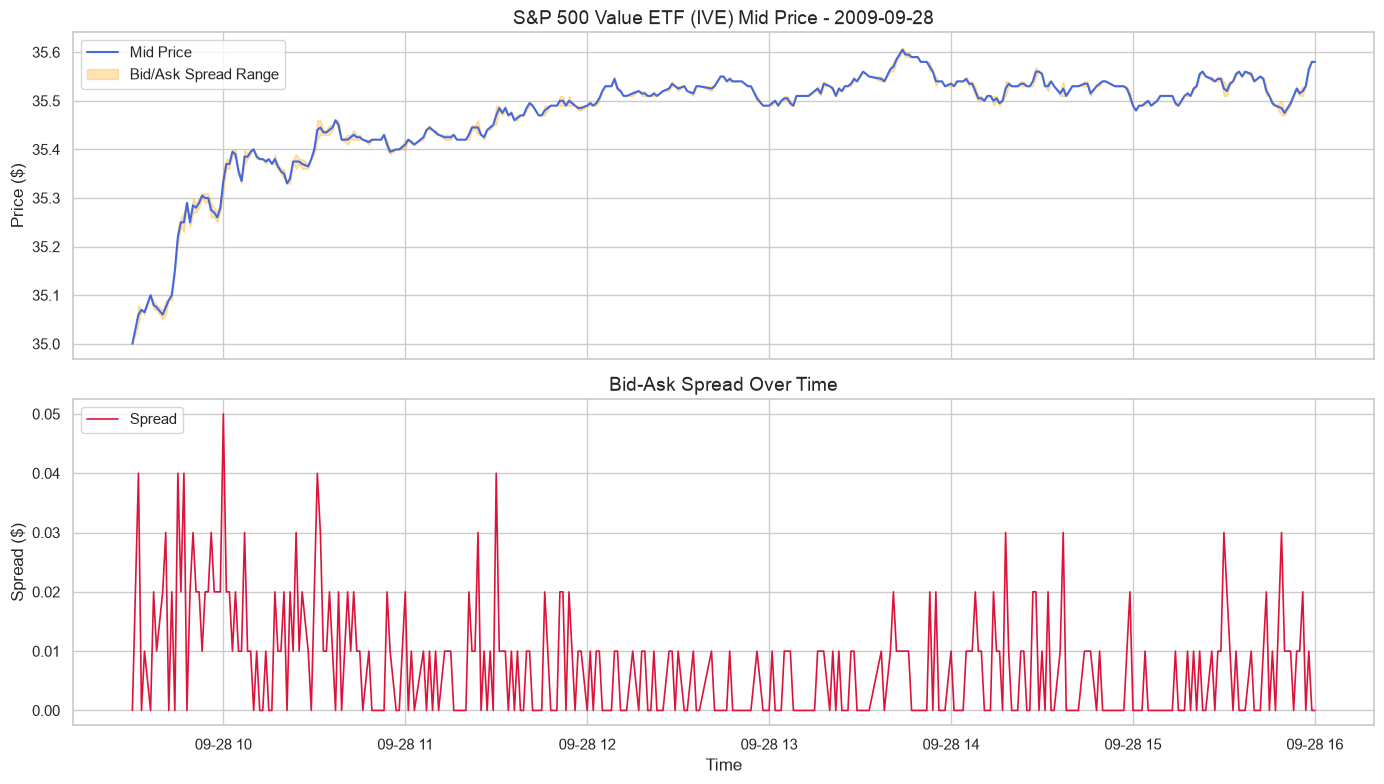

In [5]:
# Select the first day in the dataset
sample_date = df.index[0].strftime('%Y-%m-%d')
print(f"Plotting for sample date: {sample_date}")
df_day = df.loc[sample_date]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 8))

# Plot Mid Price & Bid/Ask Range
ax1.plot(df_day.index, df_day['Mid_Price'], label='Mid Price', color='royalblue', linewidth=1.5)
ax1.fill_between(df_day.index, df_day['BidClose'], df_day['AskClose'], alpha=0.3, color='orange', label='Bid/Ask Spread Range')
ax1.set_title(f'S&P 500 Value ETF (IVE) Mid Price - {sample_date}', fontsize=14)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.legend(loc='upper left')

# Plot Spread
ax2.plot(df_day.index, df_day['Spread'], color='crimson', label='Spread', linewidth=1.2)
ax2.set_title('Bid-Ask Spread Over Time', fontsize=14)
ax2.set_ylabel('Spread ($)', fontsize=12)
ax2.set_xlabel('Time', fontsize=12)
ax2.legend(loc='upper left')

plt.tight_layout()
# Save figure to file
plt.savefig('market_exploration.png', dpi=300)
plt.show()

### Structuring Data for a State-based JEPA Model

In a state-based JEPA model:
* **Context (Historical State Sequence):** We feed the encoder a window of past states (e.g., $N = 60$ minutes of features).
* **Target (Future State Sequence):** The model predicts the representations of the future states (e.g., $M = 15$ minutes of features).

Let's write a utility function to chunk the dataframe into sequential context/target sliding windows.

In [6]:
def create_jepa_datasets(data, context_len=60, target_len=15):
    """
    Creates sliding windows of context and target states.
    """
    # Select features to represent the market state at each minute
    features = ['Mid_Price', 'Spread', 'Log_Return']
    df_clean = data[features].dropna()
    
    # Convert to matrix
    state_matrix = df_clean.values
    
    # Normalize states (normally you fit a scaler on train and apply to val/test)
    state_mean = state_matrix.mean(axis=0)
    state_std = state_matrix.std(axis=0)
    normalized_states = (state_matrix - state_mean) / state_std
    
    X, Y = [], []
    # Create sliding windows
    for i in range(len(normalized_states) - context_len - target_len + 1):
        context = normalized_states[i : i + context_len]
        target = normalized_states[i + context_len : i + context_len + target_len]
        X.append(context)
        Y.append(target)
        
    return np.array(X), np.array(Y)

# Create sample datasets
context_len = 60   # 1 hour of history
target_len = 15    # 15 minutes of future to predict

contexts, targets = create_jepa_datasets(df, context_len=context_len, target_len=target_len)
print(f"Context sequence dataset shape: {contexts.shape} (Num Sequences x Context Length x State Dim)")
print(f"Target sequence dataset shape:  {targets.shape} (Num Sequences x Target Length x State Dim)")

Context sequence dataset shape: (1394471, 60, 3) (Num Sequences x Context Length x State Dim)
Target sequence dataset shape:  (1394471, 15, 3) (Num Sequences x Target Length x State Dim)
